In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Eid_Sales_Data.csv" , encoding="unicode_escape")
df.rename(columns={'State': 'City'}, inplace=True)
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,City,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Kiran Ashraf,P00125942,F,26-35,28,0,Quetta,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Zoya Nasir,P00110942,F,26-35,35,1,Hyderabad,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Osheen Malik,P00118542,F,26-35,35,1,Faisalabad,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Shahid Afridi,P00237842,M,0-17,16,0,Karachi,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Zohaib Hassan,P00057942,M,26-35,28,1,Gwadar,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
df.shape

(11251, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   City              11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 2.0 MB


In [5]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [6]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,City,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Kiran Ashraf,P00125942,F,26-35,28,0,Quetta,Western,Healthcare,Auto,1,23952.00
1,1000732,Zoya Nasir,P00110942,F,26-35,35,1,Hyderabad,Southern,Govt,Auto,3,23934.00
2,1001990,Osheen Malik,P00118542,F,26-35,35,1,Faisalabad,Central,Automobile,Auto,3,23924.00
3,1001425,Shahid Afridi,P00237842,M,0-17,16,0,Karachi,Southern,Construction,Auto,2,23912.00
4,1000588,Zohaib Hassan,P00057942,M,26-35,28,1,Gwadar,Western,Food Processing,Auto,2,23877.00
5,1000588,Zohaib Hassan,P00057942,M,26-35,28,1,Islamabad,Northern,Food Processing,Auto,1,23877.00
6,1001132,Fabiha Sherazi,P00018042,F,18-25,25,1,Faisalabad,Central,Lawyer,Auto,4,23841.00
7,1002092,Iman Ali,P00273442,F,55+,61,0,Quetta,Western,IT Sector,Auto,1,NaN
8,1003224,Parvez Musharraf,P00205642,M,26-35,35,0,Faisalabad,Central,Govt,Auto,2,23809.00
9,1003650,Ozma Farooq,P00031142,F,26-35,26,1,Hyderabad,Southern,Media,Auto,4,23799.99


In [7]:
df.isnull().value_counts()

User_ID  Cust_name  Product_ID  Gender  Age Group  Age    Marital_Status  City   Zone   Occupation  Product_Category  Orders  Amount
False    False      False       False   False      False  False           False  False  False       False             False   False     11239
                                                                                                                              True         12
Name: count, dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(11239, 13)

In [10]:
df['Amount'] = df['Amount'].astype('int')

In [11]:
df[['Amount','Orders', 'Age']].describe()

,Amount,Orders,Age
count,11239.000000,11239.000000,11239.000000
mean,9453.610553,2.489634,35.410357
std,5222.355168,1.114967,12.753866
min,188.000000,1.000000,12.000000
25%,5443.000000,2.000000,27.000000
50%,8109.000000,2.000000,33.000000
75%,12675.000000,3.000000,43.000000
max,23952.000000,4.000000,92.000000


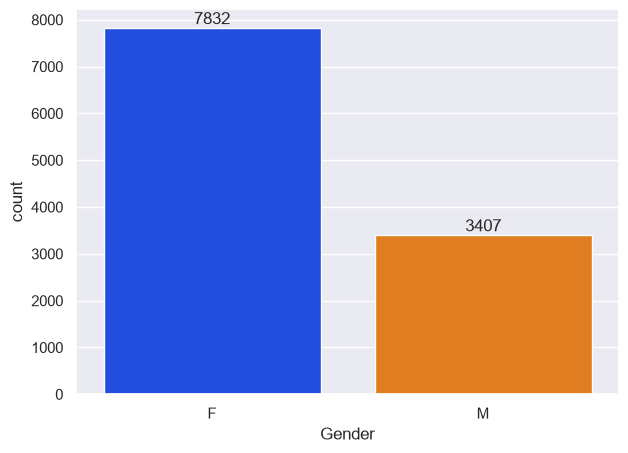

In [29]:
sns.set(rc = {'figure.figsize' : (7,5)})
cpltGen = sns.countplot(x = 'Gender' , data= df,palette='bright') #cpltGen means countplot of Gender column
#This for function i used for showing values of gender in countplot
for barval in cpltGen.containers:
     cpltGen.bar_label(barval)
plt.show()

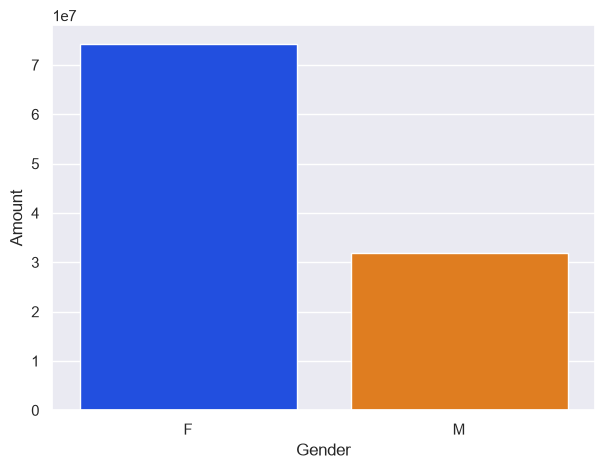

In [30]:
#PpowGen means Purchasing power according to Gender
PpowGen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False ) 
sns.set(rc = {'figure.figsize' : (7,5)})

sns.barplot(x = 'Gender' , y = 'Amount' , data=PpowGen, palette='bright')
plt.show()

**Females account for 70% of total sales, driven mainly by a larger customer base rather than higher spending per order Average order value is nearly identical between genders**


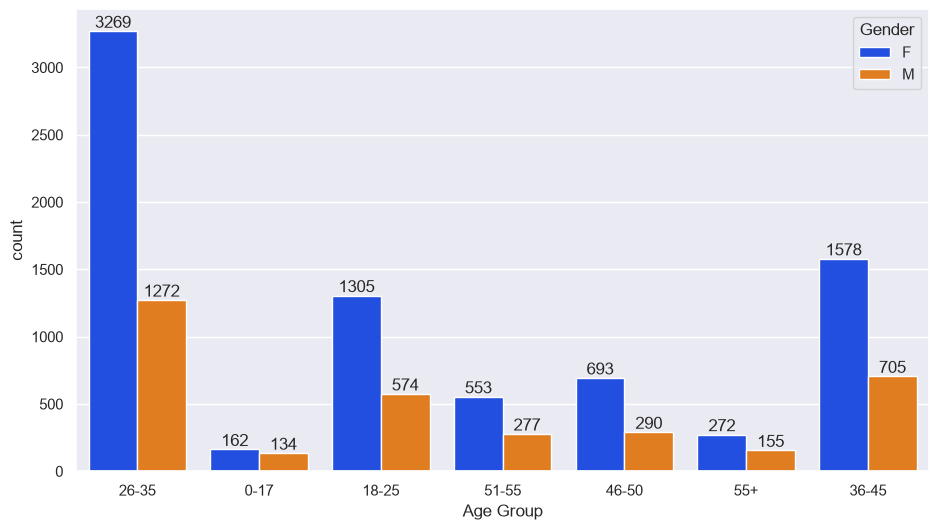

In [31]:
sns.set(rc = {'figure.figsize' : (11,6)})
AgeGrSa = sns.countplot(x = "Age Group" , hue="Gender", data=df , palette="bright")
#This for function i used for showing values of sales acorrding to Age Group in countplot
for barval in AgeGrSa.containers:
     AgeGrSa.bar_label(barval)
plt.show()

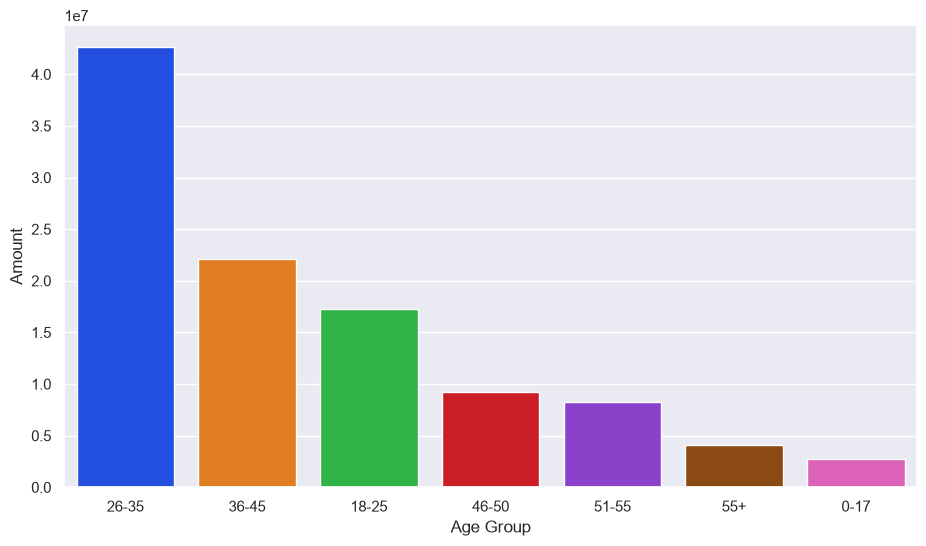

In [32]:
ToAmAgeGr = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False )
sns.set(rc = {'figure.figsize' : (11,6)})
sns.barplot(x = 'Age Group' , y = 'Amount' , data=ToAmAgeGr, palette='bright')
plt.show()

**From All this above plots we can see the most purchase are from females and specifically over 60% are coming from Age-Group of
  26-45**

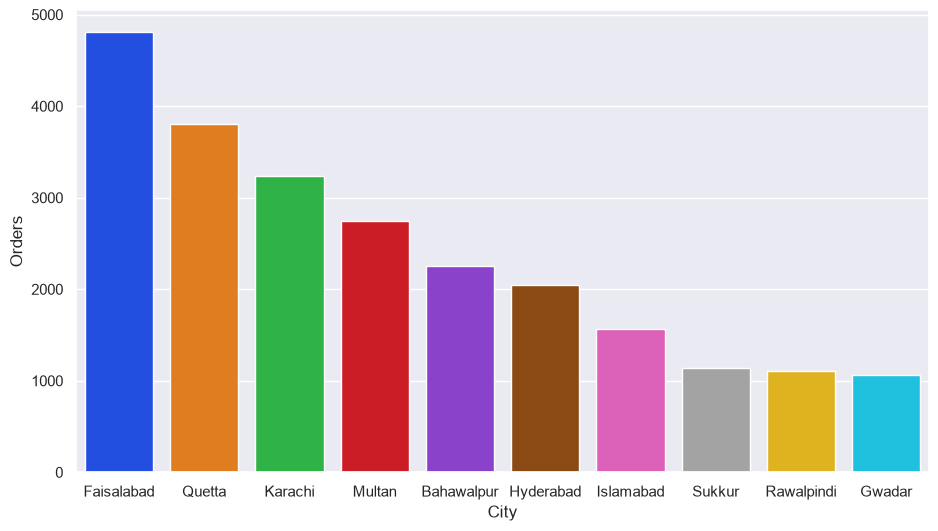

In [33]:
State_Sale = df.groupby(['City'], as_index=False)['Orders'].sum().sort_values(by = 'Orders' , ascending=False ).head(10)

sns.set(rc = {'figure.figsize' : (11,6)})
sns.barplot(x = 'City' , y = 'Orders' , data=State_Sale, palette='bright')
plt.show()

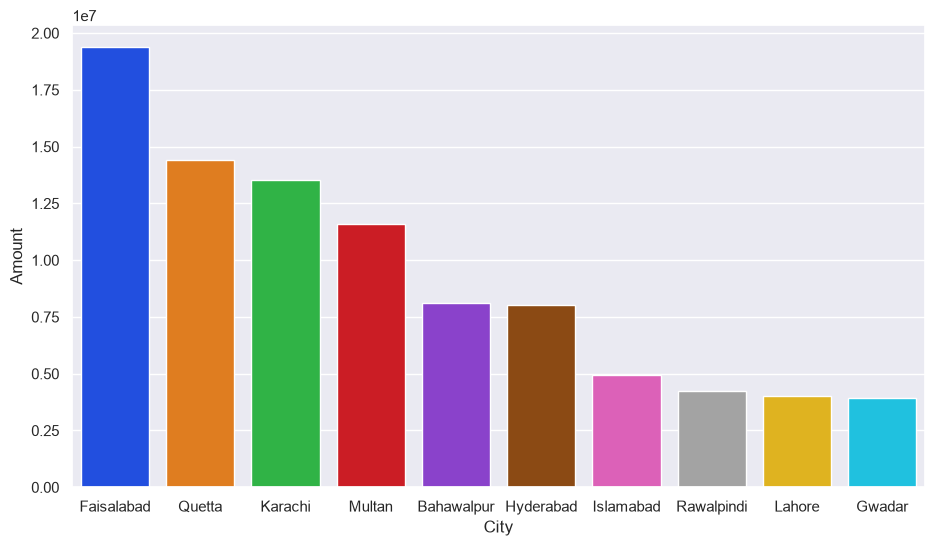

In [34]:
Cities_Sale = df.groupby(['City'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False ).head(10)

sns.set(rc = {'figure.figsize' : (11,6)})
sns.barplot(x = 'City' , y = 'Amount' , data=Cities_Sale, palette='bright')
plt.show()

**By this charts we can see our top Sales like more than 50% are from mainly 4 cities Faisalabad,Quetta,Karachi and Multan**

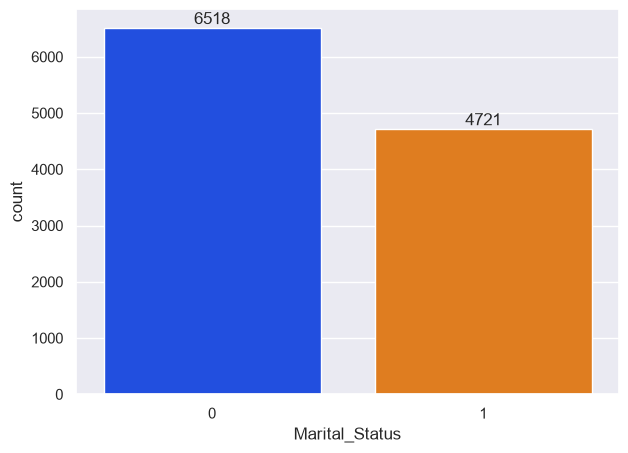

In [35]:
sns.set(rc = {'figure.figsize' : (7,5)})
Sales_by_MarrStatus = sns.countplot(x = 'Marital_Status' , data=df, palette='bright')

for barval in Sales_by_MarrStatus.containers:
     Sales_by_MarrStatus.bar_label(barval)
plt.show()

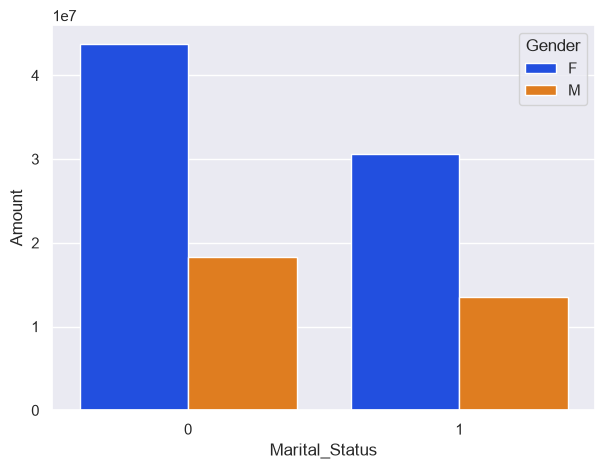

In [36]:
Sales_by_MarrStatus2 = df.groupby(['Marital_Status','Gender'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False )

sns.set(rc = {'figure.figsize' : (7,5)})
sns.barplot(x = 'Marital_Status' , y = 'Amount' , hue='Gender' , data=Sales_by_MarrStatus2, palette='bright')
plt.show()

**From above graphs we can see most of the buyers are married females and they also have high purchasing power**

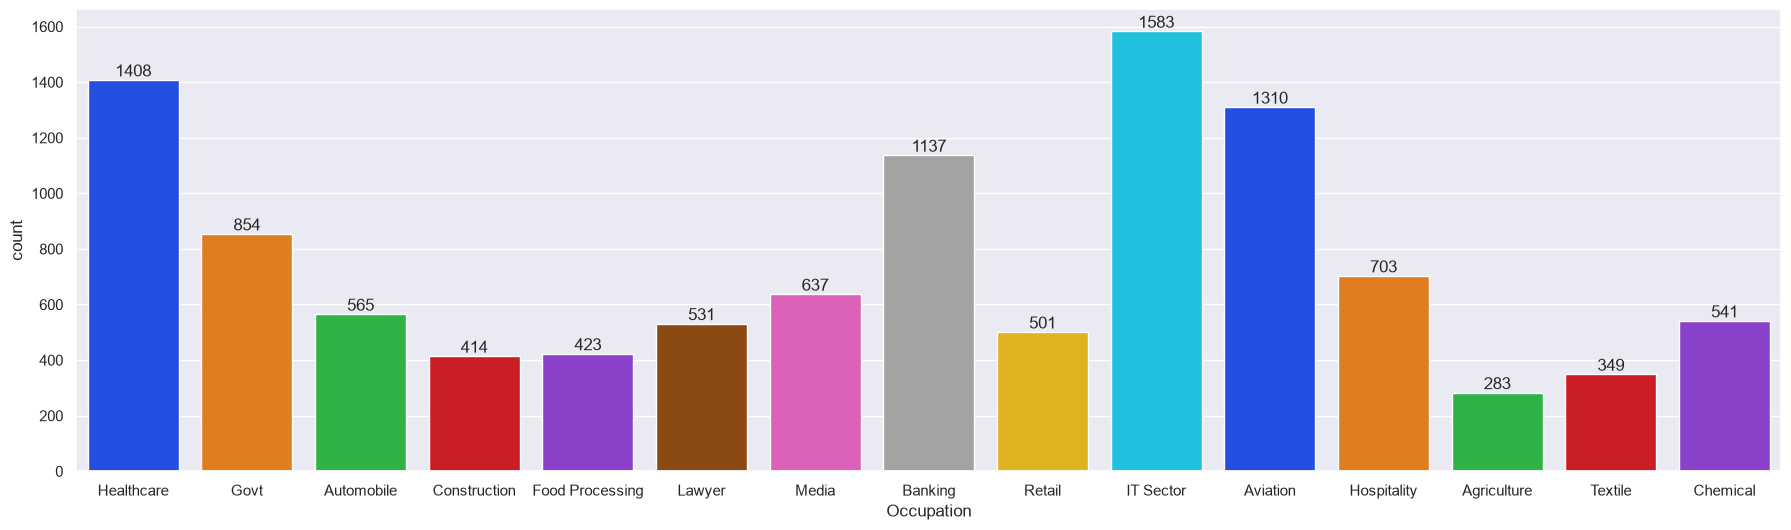

In [37]:
sns.set(rc = {'figure.figsize' : (22,6)})
occupation_Sales = sns.countplot(x = 'Occupation' , data=df, palette='bright')

for barval in occupation_Sales.containers:
     occupation_Sales.bar_label(barval)
plt.show()

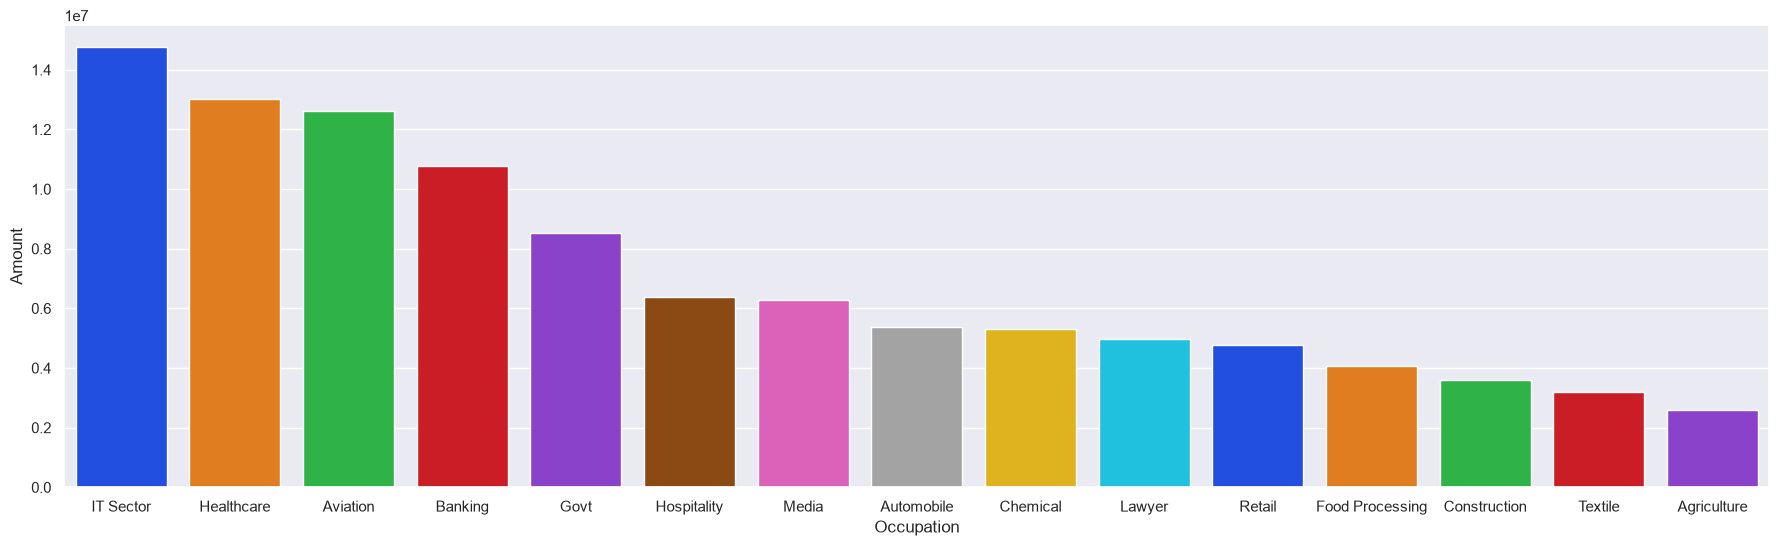

In [38]:
occupation_Sales2 = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False )

sns.set(rc = {'figure.figsize' : (22,6)})
sns.barplot(x = 'Occupation' , y = 'Amount' , data=occupation_Sales2, palette='bright')
plt.show()

**From above plots we can see the most sales or amount in sales according to Occupation is from IT,Healthcare,Aviation and 
Banking sectors**

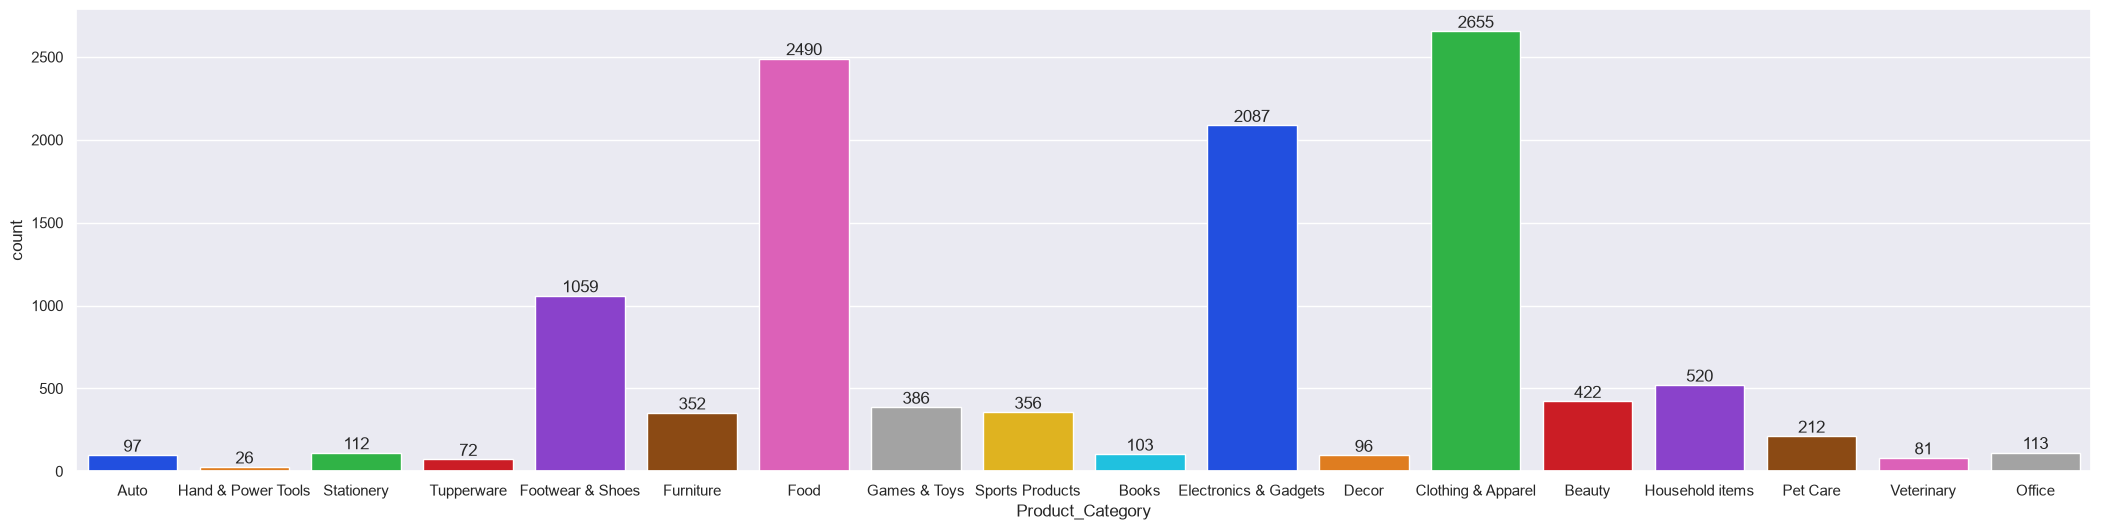

In [39]:
sns.set(rc = {'figure.figsize' : (26,6)})
Prod_Sales = sns.countplot(x = 'Product_Category' , data=df, palette='bright')

for barval in Prod_Sales.containers:
     Prod_Sales.bar_label(barval)
plt.show()

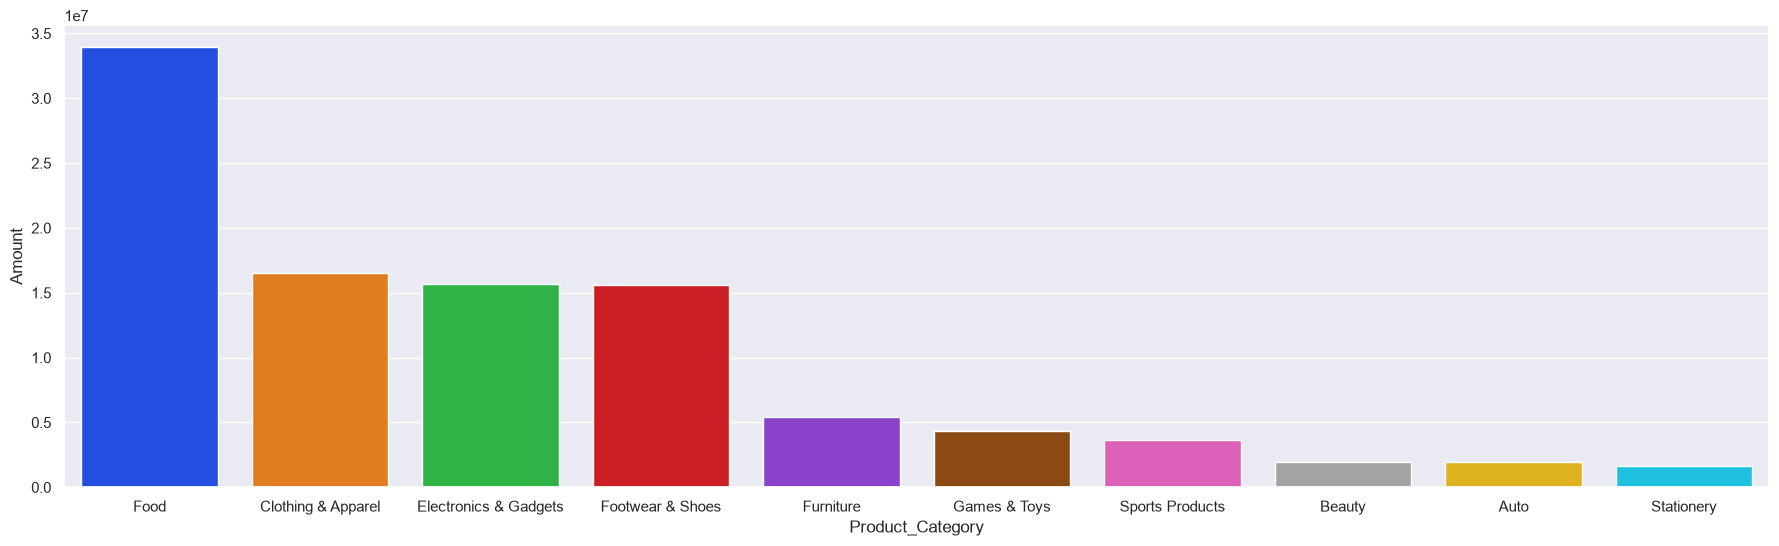

In [40]:
Prod_Sales2 = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by = 'Amount' , ascending=False ).head(10)

sns.set(rc = {'figure.figsize' : (22,6)})
sns.barplot(x = 'Product_Category' , y = 'Amount' , data=Prod_Sales2, palette='bright')
plt.show()

**From the above we can see most of sales according to product category are in Food,Clothing & Apparel,Electronics & Gadgets
and Footwear & Shoes Categories**

***Conclusion***

*****Married Females age group of 26-45 from the Faisalabad, Quetta , Karachi and Multan working in IT, Healthcare, Aviation and Banking sectors are most likely to buy from
Food,Clothing & Apparel and Electronics & Gadgets Category*****